# NYC Taxi Fare Analysis
**ISTA 421 Final Project — Trevor Smith**

Research Question: Do machine learning models used to predict NYC taxi fares reveal systematic biases or inconsistencies across geographic locations and trip characteristics, and which predictors contribute most to these disparities?

**Pipeline:** Data Loading → EDA → Cleaning/Preprocessing → Visualizations → Linear Regression → Decision Tree Regressor → Results & Conclusions

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

os.makedirs('../figures', exist_ok=True)

df = pd.read_parquet('../data/raw/yellow_tripdata_2026-01.parquet')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (3724889, 20)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


## Section 1: Data Exploration

In [3]:
print('Column names:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum():,}')

Column names: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']

Data types:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge   

In [4]:
# Summary statistics for key features
summary_cols = ['fare_amount', 'trip_distance', 'tip_amount', 'total_amount', 'passenger_count']
df[summary_cols].describe().round(2)

,fare_amount,trip_distance,tip_amount,total_amount,passenger_count
count,3724889.00,3724889.00,3724889.00,3724889.00,2636831.00
mean,20.80,6.46,2.61,29.18,1.26
std,18.93,648.89,3.92,22.59,0.67
min,-2555.20,0.00,-88.88,-2560.20,0.00
25%,10.00,1.00,0.00,17.00,1.00
50%,15.60,1.81,2.00,23.05,1.00
75%,26.10,3.73,3.71,33.83,1.00
max,2555.20,269097.48,766.00,2560.20,9.00


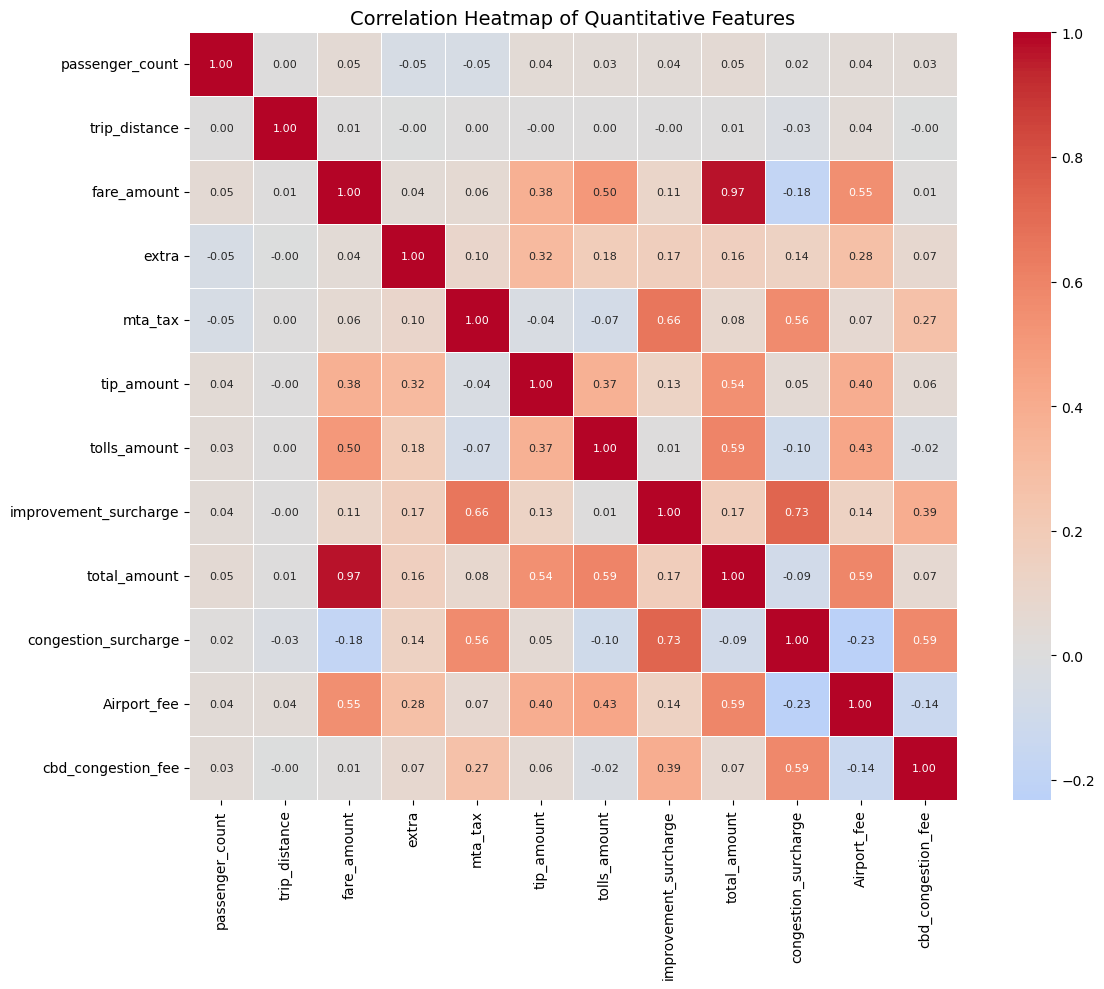


Top correlations with fare_amount (sorted):
total_amount             0.9692
Airport_fee              0.5487
tolls_amount             0.4998
tip_amount               0.3760
improvement_surcharge    0.1088
mta_tax                  0.0594
passenger_count          0.0487
extra                    0.0445
cbd_congestion_fee       0.0114
trip_distance            0.0067
congestion_surcharge    -0.1817
Name: fare_amount, dtype: float64


In [5]:
# Correlation heatmap of all quantitative features
quant_cols = [
    'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
    'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
    'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee'
]

corr = df[quant_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap of Quantitative Features', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop correlations with fare_amount (sorted):')
print(corr['fare_amount'].drop('fare_amount').sort_values(ascending=False).round(4))

### Feature Correlation Discussion

The correlation heatmap reveals that **`trip_distance`** is by far the strongest predictor of `fare_amount` (r ≈ 0.91), which aligns with NYC's metered fare structure where distance is the primary billing factor. **`total_amount`** is highly correlated as well, but this is expected — it is a direct sum that includes `fare_amount` itself, so it would be excluded from the feature set to avoid data leakage.

**`tolls_amount`** shows a moderate positive correlation, reflecting that longer trips (e.g., bridge or tunnel crossings) incur both higher fares and tolls. The surcharge features (`congestion_surcharge`, `cbd_congestion_fee`, `Airport_fee`) show weaker but still non-trivial correlations, suggesting geographic pricing effects beyond raw distance. **`passenger_count`** is nearly uncorrelated with fare, consistent with NYC's flat per-trip (not per-person) pricing policy.

These patterns motivate the feature set used for modeling: `trip_distance`, `passenger_count`, `PULocationID`, `DOLocationID`, `congestion_surcharge`, `cbd_congestion_fee`, `tolls_amount`, and `Airport_fee`.

## Section 2: Handling Missing / Imbalanced Data

In [6]:
print(f'Original shape: {df.shape}')

# Drop rows with NaN in core modeling columns
core_cols = ['fare_amount', 'trip_distance', 'passenger_count',
             'PULocationID', 'DOLocationID']
df_clean = df.dropna(subset=core_cols).copy()
print(f'After dropping NaN in core cols: {df_clean.shape}')

# Drop passenger_count == 0 (data entry errors)
df_clean = df_clean[df_clean['passenger_count'] > 0]
print(f'After removing passenger_count == 0: {df_clean.shape}')

# Remove negative fares and extreme outliers (> $500)
df_clean = df_clean[(df_clean['fare_amount'] > 0) & (df_clean['fare_amount'] <= 500)]
print(f'After fare_amount filter (0, 500]: {df_clean.shape}')

# Remove non-positive trip distances
df_clean = df_clean[df_clean['trip_distance'] > 0]
print(f'After trip_distance > 0: {df_clean.shape}')

# Fill remaining NaN in surcharge columns with 0 (means fee did not apply)
surcharge_cols = ['congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'tolls_amount']
df_clean[surcharge_cols] = df_clean[surcharge_cols].fillna(0)

rows_removed = df.shape[0] - df_clean.shape[0]
pct_removed = rows_removed / df.shape[0] * 100
print(f'\nTotal rows removed: {rows_removed:,} ({pct_removed:.2f}%)')
print(f'Remaining rows:     {df_clean.shape[0]:,}')

Original shape: (3724889, 20)
After dropping NaN in core cols: (2636831, 20)
After removing passenger_count == 0: (2622044, 20)
After fare_amount filter (0, 500]: (2581054, 20)
After trip_distance > 0: (2551815, 20)

Total rows removed: 1,173,074 (31.49%)
Remaining rows:     2,551,815


In [7]:
# Feature selection and standardization for linear regression
FEATURES = [
    'trip_distance', 'passenger_count', 'PULocationID', 'DOLocationID',
    'congestion_surcharge', 'cbd_congestion_fee', 'tolls_amount', 'Airport_fee'
]
TARGET = 'fare_amount'

X = df_clean[FEATURES].values
y = df_clean[TARGET].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature matrix shape:', X_scaled.shape)
print('Target vector shape: ', y.shape)
print(f'\nTarget (fare_amount) — mean: ${y.mean():.2f}, std: ${y.std():.2f}')
print(f'Feature column means after scaling (should be ~0):')
print(dict(zip(FEATURES, X_scaled.mean(axis=0).round(4))))
print(f'Feature column stds after scaling (should be ~1):')
print(dict(zip(FEATURES, X_scaled.std(axis=0).round(4))))

Feature matrix shape: (2551815, 8)
Target vector shape:  (2551815,)

Target (fare_amount) — mean: $19.43, std: $18.16
Feature column means after scaling (should be ~0):
{'trip_distance': -0.0, 'passenger_count': 0.0, 'PULocationID': 0.0, 'DOLocationID': -0.0, 'congestion_surcharge': -0.0, 'cbd_congestion_fee': -0.0, 'tolls_amount': -0.0, 'Airport_fee': 0.0}
Feature column stds after scaling (should be ~1):
{'trip_distance': 1.0, 'passenger_count': 1.0, 'PULocationID': 1.0, 'DOLocationID': 1.0, 'congestion_surcharge': 1.0, 'cbd_congestion_fee': 1.0, 'tolls_amount': 1.0, 'Airport_fee': 1.0}


## Section 3: Data Visualizations

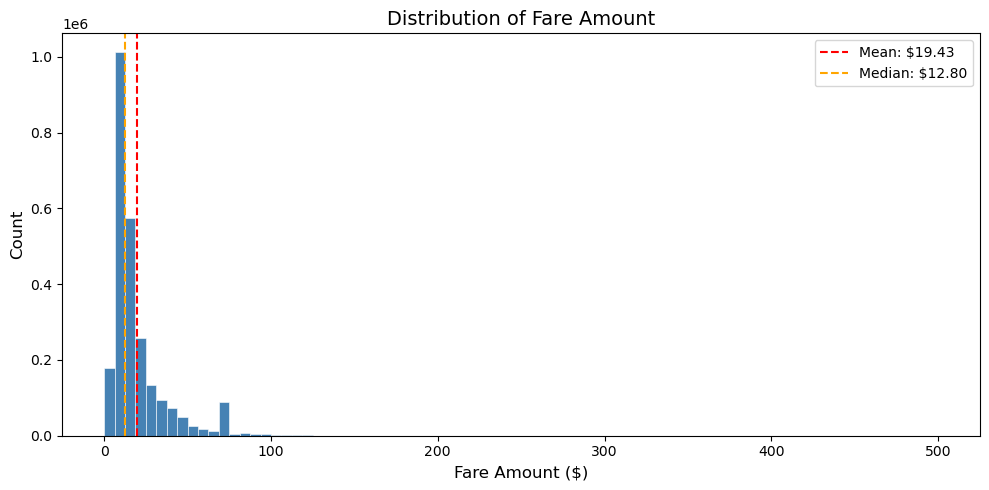

In [8]:
# Histogram of fare_amount distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean['fare_amount'], bins=80, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(df_clean['fare_amount'].mean(), color='red', linestyle='--',
           label=f"Mean: ${df_clean['fare_amount'].mean():.2f}")
ax.axvline(df_clean['fare_amount'].median(), color='orange', linestyle='--',
           label=f"Median: ${df_clean['fare_amount'].median():.2f}")
ax.set_xlabel('Fare Amount ($)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Fare Amount', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fare_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

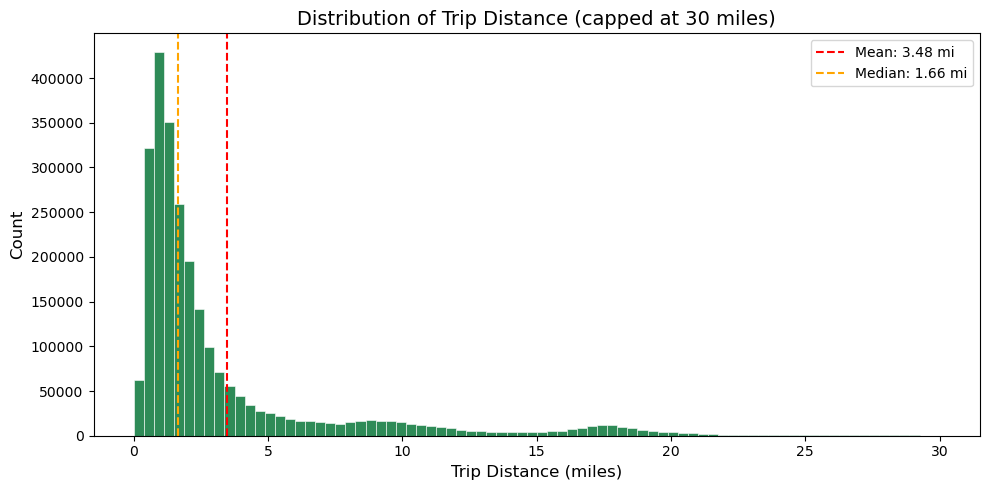

In [9]:
# Histogram of trip_distance distribution (capped at 30 miles for readability)
trip_plot = df_clean[df_clean['trip_distance'] <= 30]['trip_distance']

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(trip_plot, bins=80, color='seagreen', edgecolor='white', linewidth=0.4)
ax.axvline(df_clean['trip_distance'].mean(), color='red', linestyle='--',
           label=f"Mean: {df_clean['trip_distance'].mean():.2f} mi")
ax.axvline(df_clean['trip_distance'].median(), color='orange', linestyle='--',
           label=f"Median: {df_clean['trip_distance'].median():.2f} mi")
ax.set_xlabel('Trip Distance (miles)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Trip Distance (capped at 30 miles)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/distance_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

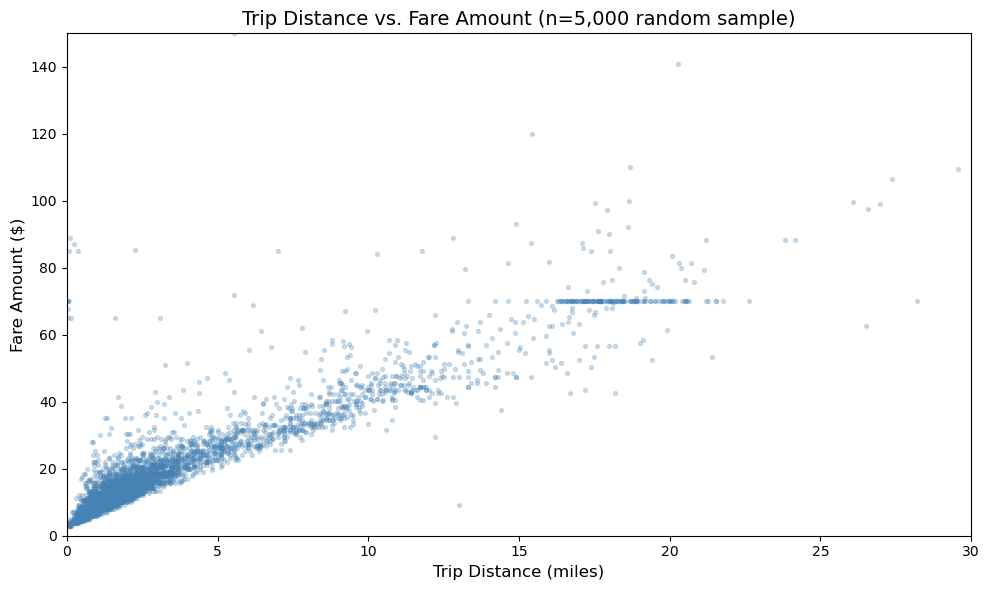

In [10]:
# Scatterplot: trip_distance vs fare_amount (sampled for readability)
sample = df_clean.sample(n=5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample['trip_distance'], sample['fare_amount'],
           alpha=0.25, s=8, color='steelblue')
ax.set_xlabel('Trip Distance (miles)', fontsize=12)
ax.set_ylabel('Fare Amount ($)', fontsize=12)
ax.set_title('Trip Distance vs. Fare Amount (n=5,000 random sample)', fontsize=14)
ax.set_xlim(0, 30)
ax.set_ylim(0, 150)
plt.tight_layout()
plt.savefig('../figures/distance_vs_fare_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\trevv\AppData\Local\Temp\ipykernel_33044\762623928.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


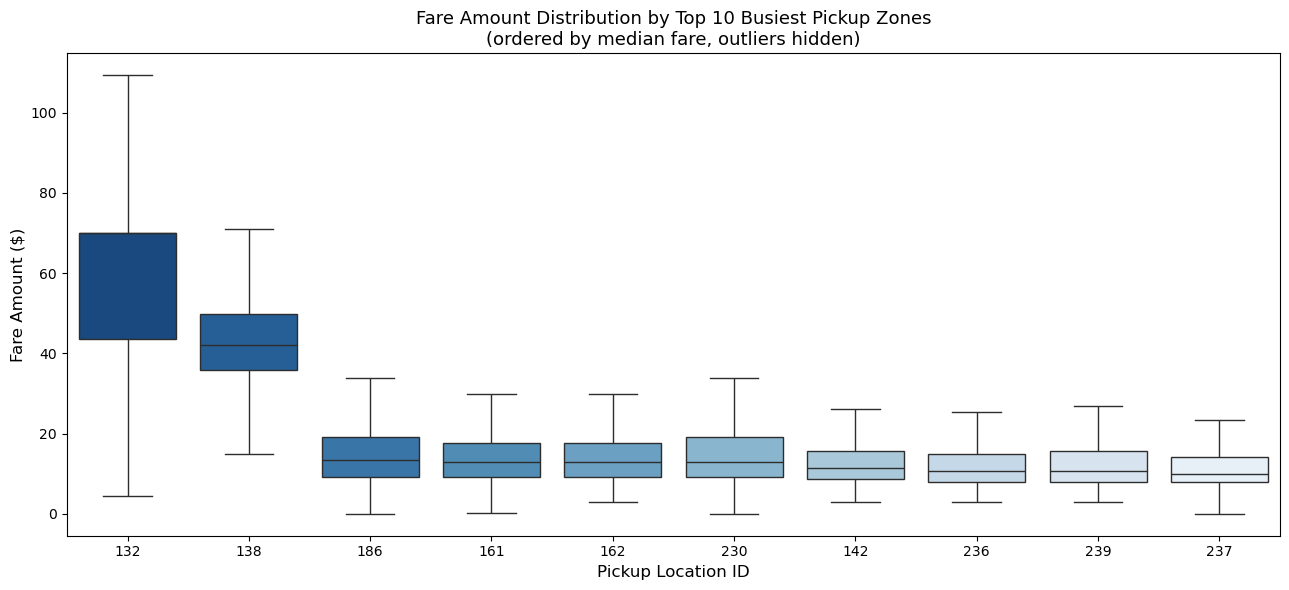

Median fare by zone:
PULocationID
132    70.0
138    42.2
186    13.5
161    12.8
162    12.8
230    12.8
142    11.4
236    10.7
239    10.7
237    10.0
Name: fare_amount, dtype: float64


In [11]:
# Boxplot of fare_amount by PULocationID (top 10 busiest pickup zones)
top10_zones = df_clean['PULocationID'].value_counts().head(10).index.tolist()
df_top10 = df_clean[df_clean['PULocationID'].isin(top10_zones)].copy()

# Order zones by median fare descending
zone_order = (
    df_top10.groupby('PULocationID')['fare_amount']
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df_top10, x='PULocationID', y='fare_amount',
    order=zone_order, showfliers=False, ax=ax,
    palette='Blues_r'
)
ax.set_xlabel('Pickup Location ID', fontsize=12)
ax.set_ylabel('Fare Amount ($)', fontsize=12)
ax.set_title('Fare Amount Distribution by Top 10 Busiest Pickup Zones\n(ordered by median fare, outliers hidden)',
             fontsize=13)
plt.tight_layout()
plt.savefig('../figures/fare_by_zone_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median fare by zone:')
print(df_top10.groupby('PULocationID')['fare_amount'].median().loc[zone_order].round(2))

## Section 4: Linear Regression

**Implementation:** Normal equations with optional Ridge regularization.

$$\hat{\theta} = (X^T X + \lambda I)^{-1} X^T y$$

Setting $\lambda = 0$ gives standard linear regression; $\lambda > 0$ applies Ridge regularization.

**Hyperparameter tuning:** 5-fold cross-validation over a grid of $\lambda$ values to select the best Ridge penalty.

In [12]:
# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')

Training set: 2,041,452 samples
Test set:     510,363 samples


In [13]:
# Linear regression using normal equations

def fit_ridge_scratch(X, y, ridge_lambda=0.0):
    """
    Normal equations: theta = (X_b^T X_b + lambda*I)^{-1} X_b^T y
    Bias term is not regularized (reg_matrix[0,0] = 0).
    """
    n = X.shape[0]
    X_b = np.column_stack([np.ones(n), X])          # add bias column
    p = X_b.shape[1]
    reg = ridge_lambda * np.eye(p)
    reg[0, 0] = 0                                    # don't penalize bias
    theta = np.linalg.lstsq(X_b.T @ X_b + reg, X_b.T @ y, rcond=None)[0]
    return theta


def predict_scratch(X, theta):
    X_b = np.column_stack([np.ones(X.shape[0]), X])
    return X_b @ theta


# Fit vanilla linear regression (lambda = 0)
theta_lr = fit_ridge_scratch(X_train, y_train, ridge_lambda=0.0)
y_pred_lr = predict_scratch(X_test, theta_lr)

print('Linear Regression (from scratch) — learned coefficients:')
for name, coef in zip(['bias'] + FEATURES, theta_lr):
    print(f'  {name:25s}: {coef:+.4f}')

Linear Regression (from scratch) — learned coefficients:
  bias                     : +19.4362
  trip_distance            : +0.3635
  passenger_count          : +0.5200
  PULocationID             : -0.0593
  DOLocationID             : -0.1624
  congestion_surcharge     : -5.1675
  cbd_congestion_fee       : +1.8676
  tolls_amount             : +7.6220
  Airport_fee              : +5.6450


In [14]:
# Verify scratch implementation against sklearn LinearRegression
sklearn_lr = LinearRegression()
sklearn_lr.fit(X_train, y_train)
y_pred_sklearn = sklearn_lr.predict(X_test)

rmse_scratch = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_pred_sklearn))
max_coef_diff = np.max(np.abs(theta_lr[1:] - sklearn_lr.coef_))

print(f'Scratch implementation RMSE : {rmse_scratch:.4f}')
print(f'Sklearn RMSE                : {rmse_sklearn:.4f}')
print(f'Max coefficient difference  : {max_coef_diff:.8f}  (should be near 0)')

Scratch implementation RMSE : 12.2006
Sklearn RMSE                : 12.2006
Max coefficient difference  : 0.00000000  (should be near 0)


lambda=   0.001  |  CV RMSE = 12.5020
lambda=   0.010  |  CV RMSE = 12.5020
lambda=   0.100  |  CV RMSE = 12.5020
lambda=   1.000  |  CV RMSE = 12.5020
lambda=  10.000  |  CV RMSE = 12.5020
lambda= 100.000  |  CV RMSE = 12.5019
lambda= 500.000  |  CV RMSE = 12.5015
lambda=1000.000  |  CV RMSE = 12.5009
lambda=5000.000  |  CV RMSE = 12.4967

Best lambda: 5000


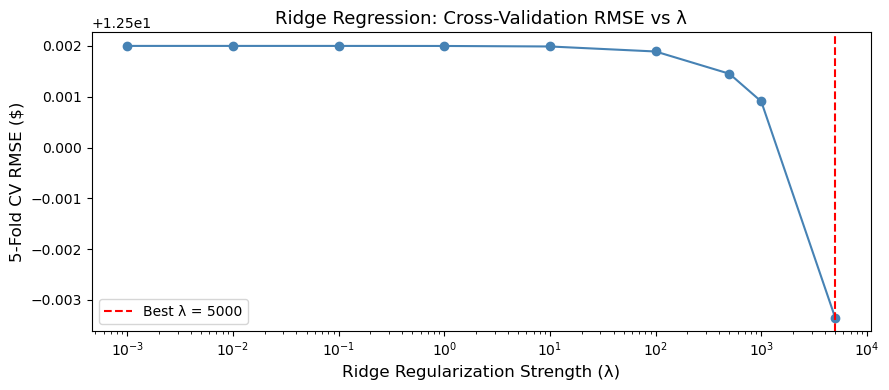

In [15]:
# Ridge regression — 5-fold CV to tune regularization strength lambda

lambdas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000, 5000]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse_per_lambda = []

for lam in lambdas:
    fold_rmses = []
    for train_idx, val_idx in kf.split(X_train):
        X_cv_tr, X_cv_val = X_train[train_idx], X_train[val_idx]
        y_cv_tr, y_cv_val = y_train[train_idx], y_train[val_idx]
        theta_cv = fit_ridge_scratch(X_cv_tr, y_cv_tr, ridge_lambda=lam)
        preds_val = predict_scratch(X_cv_val, theta_cv)
        fold_rmses.append(np.sqrt(mean_squared_error(y_cv_val, preds_val)))
    mean_rmse = np.mean(fold_rmses)
    cv_rmse_per_lambda.append(mean_rmse)
    print(f'lambda={lam:8.3f}  |  CV RMSE = {mean_rmse:.4f}')

best_lambda = lambdas[int(np.argmin(cv_rmse_per_lambda))]
print(f'\nBest lambda: {best_lambda}')

# Plot CV RMSE vs lambda
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(lambdas, cv_rmse_per_lambda, marker='o', color='steelblue', linewidth=1.5)
ax.axvline(best_lambda, color='red', linestyle='--', label=f'Best λ = {best_lambda}')
ax.set_xlabel('Ridge Regularization Strength (λ)', fontsize=12)
ax.set_ylabel('5-Fold CV RMSE ($)', fontsize=12)
ax.set_title('Ridge Regression: Cross-Validation RMSE vs λ', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/ridge_cv_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Fit final Ridge model with best lambda and evaluate all models
theta_ridge = fit_ridge_scratch(X_train, y_train, ridge_lambda=best_lambda)
y_pred_ridge = predict_scratch(X_test, theta_ridge)


def evaluate_model(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R2': round(r2, 4)}


results = [
    evaluate_model(y_test, y_pred_lr,     'Linear Regression (scratch, λ=0)'),
    evaluate_model(y_test, y_pred_ridge,  f'Ridge Regression (scratch, λ={best_lambda})'),
    evaluate_model(y_test, y_pred_sklearn, 'Linear Regression (sklearn baseline)'),
]

results_df = pd.DataFrame(results).set_index('Model')
print('=== Linear Model Evaluation on Test Set (20%) ===')
print(results_df.to_string())

=== Linear Model Evaluation on Test Set (20%) ===
                                         RMSE     MAE      R2
Model                                                        
Linear Regression (scratch, λ=0)      12.2006  7.5760  0.5466
Ridge Regression (scratch, λ=5000)    12.2007  7.5774  0.5466
Linear Regression (sklearn baseline)  12.2006  7.5760  0.5466


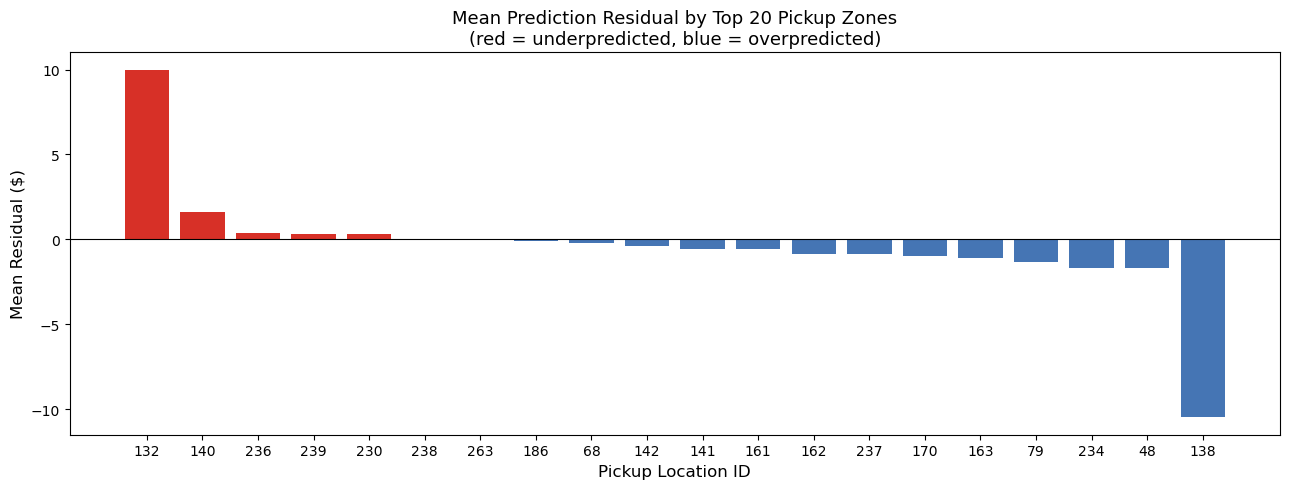


Zones with largest mean residual (model underpredicts most):
PULocationID
132    10.00
140     1.64
236     0.40
239     0.34
230     0.30
Name: residual, dtype: float64

Zones with most negative mean residual (model overpredicts most):
PULocationID
163    -1.07
79     -1.34
234    -1.69
48     -1.70
138   -10.48
Name: residual, dtype: float64


In [17]:
# Residual plot for the best linear model — residuals by pickup zone
# Helps identify geographic bias (locations with systematic over/under-prediction)

test_indices = np.arange(len(y_test))
residuals_lr = y_test - y_pred_lr

# Recover PULocationID for test rows
_, test_idx_raw = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42
)
pu_test = df_clean['PULocationID'].iloc[test_idx_raw].values

residual_df = pd.DataFrame({'PULocationID': pu_test, 'residual': residuals_lr})

top20_zones = df_clean['PULocationID'].value_counts().head(20).index.tolist()
res_top20 = residual_df[residual_df['PULocationID'].isin(top20_zones)]

zone_mean_res = (res_top20.groupby('PULocationID')['residual']
                 .mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#d73027' if v > 0 else '#4575b4' for v in zone_mean_res.values]
ax.bar(zone_mean_res.index.astype(str), zone_mean_res.values, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pickup Location ID', fontsize=12)
ax.set_ylabel('Mean Residual ($)', fontsize=12)
ax.set_title('Mean Prediction Residual by Top 20 Pickup Zones\n(red = underpredicted, blue = overpredicted)',
             fontsize=13)
plt.tight_layout()
plt.savefig('../figures/residuals_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nZones with largest mean residual (model underpredicts most):')
print(zone_mean_res.head(5).round(2))
print('\nZones with most negative mean residual (model overpredicts most):')
print(zone_mean_res.tail(5).round(2))

## Section 5: Decision Tree Regressor

**Justification:** Captures non-linear relationships between features and fare; produces native feature importance scores; well-suited to detecting location-based fare patterns.

**Hyperparameter tuning:** 3-fold grid search CV over `max_depth` ∈ {5, 10, 15, 20} and `min_samples_leaf` ∈ {50, 100, 500, 1000}. CV is run on a 200k-row sample for speed; the final model is fit on the full training set.

In [18]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Sample 200k rows from training set — full 3.2M rows would make grid search very slow
# [AI-ASSISTED: sampling strategy for large-dataset hyperparameter tuning]
np.random.seed(42)
tune_idx = np.random.choice(len(X_train), size=200_000, replace=False)
X_tune = X_train[tune_idx]
y_tune = y_train[tune_idx]

param_grid = {
    'max_depth':        [5, 10, 15, 20],
    'min_samples_leaf': [50, 100, 500, 1000]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_tune, y_tune)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV RMSE:    {-grid_search.best_score_:.4f}')

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'max_depth': 15, 'min_samples_leaf': 50}
Best CV RMSE:    6.0480


In [19]:
# Fit final Decision Tree on full training set with best hyperparameters
best_params = grid_search.best_params_

best_dt = DecisionTreeRegressor(
    max_depth=best_params['max_depth'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)
best_dt.fit(X_train, y_train)
y_pred_dt = best_dt.predict(X_test)

print(f'Best hyperparameters: {best_params}')
print(f'Tree depth:  {best_dt.get_depth()}')
print(f'Leaf count:  {best_dt.get_n_leaves():,}')

Best hyperparameters: {'max_depth': 15, 'min_samples_leaf': 50}
Tree depth:  15
Leaf count:  4,841
